## Course Announcements

Due Sunday (11:59 PM):
- Pre-course Survey
- D1
- Q2
- A1
- Group Formation Survey

Note: No class, discussion, or OH on Monday

# Data Wrangling

- `pandas`
- Where to find data?
   - Web Scraping & APIs

<center>
<img src="img/pandas.png" alt="pandas" width="600px">
</center>

Pandas is Python library for managing heterogenous data.

At its core, Pandas is used for the **DataFrame** object, which is:
- a data structure for labeled rows and columns of data
- associated methods and utilities for working with data.
- each column contains a `pandas` **Series**

## After this: 

When you are done with this notebook/lecture... the real learning can begin!

One of your best tools is [https://pandastutor.com](https://pandastutor.com)

Another is the documentation for pandas including [https://pandas.pydata.org/docs/user_guide/10min.html](https://pandas.pydata.org/docs/user_guide/10min.html)

## Setup

In [1]:
# Import standard libraries
import pandas as pd
import numpy as np

In [2]:
# reminder about tab completion and contextual help

## Loading Data

In [3]:
# Load a csv file of data
df = pd.read_csv('data/my_data.csv')

Note: there are other `pd.read_*` functions for other files types. (i.e. `pd.read_excel()` and `pd.read_json()`)

In [4]:
# Check out a few rows of the dataframe
df

,id,first_name,last_name,age,score,value
0,295,Andrea,Clark,46,-1,24547.87
1,620,Bill,Woods,46,492,46713.90
2,891,Alexander,Jacobson,48,489,32071.74
3,914,Derrick,Bradley,52,-1,30650.48
4,1736,Allison,Thomas,44,-1,9553.12
...,...,...,...,...,...,...
195,97441,Krista,Ortiz,34,-1,24074.79
196,97728,Anna,Chambers,37,598,0.00
197,98115,Jennifer,Pitts,29,606,6876.75
198,98284,Brittany,Jenkins,34,665,43525.88


Pandas DataFrame:
- Index for each row
- Column name for each column (Series)
- Stores heterogenous types

## DataFrame Information (attributes)

In [5]:
# Check how large our dataframe is
df.shape

(200, 6)

In [6]:
# Check what columns we have in our DataFrame
df.columns

Index(['id', 'first_name', 'last_name', 'age', 'score', 'value'], dtype='object')

In [7]:
# Check the datatypes of our variables
df.dtypes

id              int64
first_name     object
last_name      object
age             int64
score           int64
value         float64
dtype: object

## Slicing

In [8]:
# Slicing (Indexing): select a Series (column) using its name
df['last_name']

0         Clark
1         Woods
2      Jacobson
3       Bradley
4        Thomas
         ...   
195       Ortiz
196    Chambers
197       Pitts
198     Jenkins
199       Brown
Name: last_name, Length: 200, dtype: object

In [9]:
type(df['last_name'])

pandas.core.series.Series

In [10]:
df.loc[5:10, ['age', 'last_name']]

,age,last_name
5,57,Williams
6,46,Wood
7,50,Garcia
8,68,Coleman
9,56,Atkins
10,59,Johnson


In [11]:
# Slicing: select a row & column with 'loc'
df.loc[10, 'score']

500

#### Question #1

What would be the output of `df['age'] > 10`?

- A) subset of `df` including only rows of individuals older than 10
- B) a Series of Booleans with `True` for rows where age is greater than 10 and `False` otherwise
- C) a Series of `id`s of rows where observations are greater than 10 
- D) an error
- E) I'm lost

Link to Form: https://forms.gle/k1M6rrYjpVGdMwHk9

![](../QRCodes/02_04_pandas_logic.png)

In [12]:
## YOUR CODE HERE
df['age'] > 10

0      True
1      True
2      True
3      True
4      True
       ... 
195    True
196    True
197    True
198    True
199    True
Name: age, Length: 200, dtype: bool

In [13]:
df

,id,first_name,last_name,age,score,value
0,295,Andrea,Clark,46,-1,24547.87
1,620,Bill,Woods,46,492,46713.90
2,891,Alexander,Jacobson,48,489,32071.74
3,914,Derrick,Bradley,52,-1,30650.48
4,1736,Allison,Thomas,44,-1,9553.12
...,...,...,...,...,...,...
195,97441,Krista,Ortiz,34,-1,24074.79
196,97728,Anna,Chambers,37,598,0.00
197,98115,Jennifer,Pitts,29,606,6876.75
198,98284,Brittany,Jenkins,34,665,43525.88


In [14]:
## getting a subset using conditional logic
df_older = df[df['age'] > 40]
df_older

,id,first_name,last_name,age,score,value
0,295,Andrea,Clark,46,-1,24547.87
1,620,Bill,Woods,46,492,46713.90
2,891,Alexander,Jacobson,48,489,32071.74
3,914,Derrick,Bradley,52,-1,30650.48
4,1736,Allison,Thomas,44,-1,9553.12
...,...,...,...,...,...,...
188,94421,Tracy,Reyes,57,284,11442.11
189,94628,Shannon,Andrews,45,426,9593.03
191,95502,Julia,Oliver,57,354,23522.87
194,96371,Sherri,Austin,46,698,29412.01


## Exploring the data

- quantitative (numbers)
- qualitative (categorical)
- basic descriptive statistics

In [15]:
# Checking categorical data
df['first_name'].value_counts()

first_name
David       6
Michael     5
Eric        4
Charles     4
James       4
           ..
Alison      1
Andrew      1
Vanessa     1
Samantha    1
Katelyn     1
Name: count, Length: 134, dtype: int64

In [16]:
# Check a particular descriptive statistic
# mean(), median(), mode(), std()...
df['value'].mean()

28730.336296296293

In [17]:
# Describe a particular column
df['score'].describe()

count    200.000000
mean     416.595000
std      237.176674
min       -1.000000
25%      288.750000
50%      463.500000
75%      596.500000
max      942.000000
Name: score, dtype: float64

In [18]:
# Get descriptive statistics of all numeric columns
df.describe()

,id,age,score,value
count,200.000000,200.000000,200.000000,189.000000
mean,52929.150000,46.020000,416.595000,28730.336296
std,29414.298899,10.028582,237.176674,32493.945741
min,295.000000,14.000000,-1.000000,0.000000
25%,26709.500000,39.000000,288.750000,9593.030000
50%,54643.500000,46.000000,463.500000,17976.510000
75%,80840.750000,53.000000,596.500000,33163.310000
max,98366.000000,69.000000,942.000000,204999.960000


#### Question #2

What's the median age of the individuals in this dataset?

Link to Form: https://forms.gle/RjHPN5KsHE3jDjaNA

![](../QRCodes/02_04_pandas_median.png)

In [19]:
df['age'].describe().median()

46.010000000000005

In [20]:
## YOUR CODE HERE
df['age'].median()

46.0

## `pandas`: Common Manipulations

You'll want to be *very* familiar with a few common data manipulations when wrangling data, each of which is described below:

Manipulation | Description
-------|------------
**select** | select which columns to include in dataset
**filter** | filter dataset to only include specified rows
**mutate** | add a new column based on values in other columns
**groupby** | group values to apply a function within the specified groups
**summarize** | calculate specified summary metric of a specified variable
**arrange** | sort rows ascending or descending order of a specified column
**merge** | join separate datasets into a single dataset based on a common column



## Selecting & Dropping Columns

- include subset of columns of larger data frame

In [21]:
df.head()

,id,first_name,last_name,age,score,value
0,295,Andrea,Clark,46,-1,24547.87
1,620,Bill,Woods,46,492,46713.90
2,891,Alexander,Jacobson,48,489,32071.74
3,914,Derrick,Bradley,52,-1,30650.48
4,1736,Allison,Thomas,44,-1,9553.12


In [22]:
# specify which columns to include
select_df = df[['id', 'age', 'score', 'value']]
select_df.head()

,id,age,score,value
0,295,46,-1,24547.87
1,620,46,492,46713.90
2,891,48,489,32071.74
3,914,52,-1,30650.48
4,1736,44,-1,9553.12


In [23]:
# ...or Drop columns we don't want
# NOTE: I changed the variable name
df_drop = df.drop(labels=['first_name', 'last_name'], axis='columns')

In [24]:
# Check out the DataFrame after dropping some columns
df_drop.head()

,id,age,score,value
0,295,46,-1,24547.87
1,620,46,492,46713.90
2,891,48,489,32071.74
3,914,52,-1,30650.48
4,1736,44,-1,9553.12


In [25]:
# Drop rows we don't want
new_df = df.drop(labels=[0,2,6], axis='rows')

In [26]:
new_df

,id,first_name,last_name,age,score,value
1,620,Bill,Woods,46,492,46713.90
3,914,Derrick,Bradley,52,-1,30650.48
4,1736,Allison,Thomas,44,-1,9553.12
5,2049,Stephen,Williams,57,333,138936.92
7,2607,Amber,Garcia,50,536,9367.27
...,...,...,...,...,...,...
195,97441,Krista,Ortiz,34,-1,24074.79
196,97728,Anna,Chambers,37,598,0.00
197,98115,Jennifer,Pitts,29,606,6876.75
198,98284,Brittany,Jenkins,34,665,43525.88


#### Think-Pair-Share

What's wrong with the DataFrame after dropping? What went wrong? How do we fix it?

In [27]:
## YOUR CODE HERE
new_df = new_df.reset_index()

In [28]:
new_df

,index,id,first_name,last_name,age,score,value
0,1,620,Bill,Woods,46,492,46713.90
1,3,914,Derrick,Bradley,52,-1,30650.48
2,4,1736,Allison,Thomas,44,-1,9553.12
3,5,2049,Stephen,Williams,57,333,138936.92
4,7,2607,Amber,Garcia,50,536,9367.27
...,...,...,...,...,...,...,...
192,195,97441,Krista,Ortiz,34,-1,24074.79
193,196,97728,Anna,Chambers,37,598,0.00
194,197,98115,Jennifer,Pitts,29,606,6876.75
195,198,98284,Brittany,Jenkins,34,665,43525.88


## Filtering Data (slicing)

- include a subset (slice) of rows from larger data frame

In [29]:
# Check if we have any data from people below the age of 18
sum(df['age'] < 18)

1

In [30]:
# before filtering
df.shape

(200, 6)

In [31]:
# Select only participants who are 18 or older AND who have a score of -1
df_new = df[(df['age'] >= 18) & (df['score']==-1)]
df_new.shape

(33, 6)

## Missing Data (NaNs)

 Examples: `isnull()`, `dropna()`, `fillna()`.

In [32]:
# Check for missing values in a column (series)
df['value'].hasnans

True

In [33]:
# can operate on entire dataframe
df.isnull()

,id,first_name,last_name,age,score,value
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
195,False,False,False,False,False,False
196,False,False,False,False,False,False
197,False,False,False,False,False,False
198,False,False,False,False,False,False


In [34]:
# Check for null values
df.isnull().sum(axis='rows')

id             0
first_name     0
last_name      0
age            0
score          0
value         11
dtype: int64

In [35]:
# Have a look at the missing values
df[df['value'].isnull()]

,id,first_name,last_name,age,score,value
17,10753,Laurie,Wood,58,335,NaN
30,16263,Victor,Dawson,42,323,NaN
44,24952,James,Wright,51,399,NaN
48,26091,Marie,Wyatt,44,620,NaN
53,29566,James,Kennedy,69,224,NaN
63,35466,Samantha,Park,55,483,NaN
76,42138,John,Stuart,28,543,NaN
90,51723,Megan,Nguyen,40,443,NaN
103,55821,Sarah,Kennedy,41,709,NaN
114,61534,Alexandra,Chavez,39,598,NaN


## Dealing with Missing Data - NaNs

In [36]:
# Dealing with null values: Drop rows with missing data
print('before dropping null rows', df.shape)
no_na_df = df.dropna()
print('new shape', no_na_df.shape)

before dropping null rows (200, 6)
new shape (189, 6)


## Finding & Dealing with Bad Values

In [37]:
# Check for the properties of specific columns
df['score'].describe()

count    200.000000
mean     416.595000
std      237.176674
min       -1.000000
25%      288.750000
50%      463.500000
75%      596.500000
max      942.000000
Name: score, dtype: float64

### Think-Pair-Share

What sticks out to you in the above output?

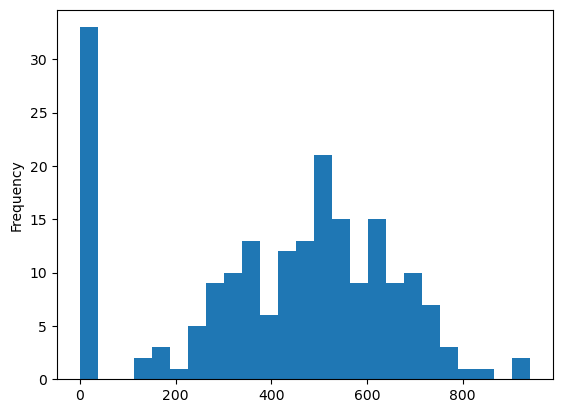

In [38]:
# Check the plot of the data for score to see the distribution
df['score'].plot(kind='hist', bins=25);

In [39]:
# Look for how many values have a -1 value in 'score'
sum(df['score'] == -1)

33

In [40]:
# Drop any row with -1 value in 'score'
df = df[df['score'] != -1]
df.shape

(167, 6)

## Creating new columns (mutating)

- `assign` can be very helpful in adding a new column
- lambda functions can be used to carry out calculations

In [41]:
# convert age in years to age in (approximate) days
df = df.assign(age_days = df['age'] * 365)
df.head()

,id,first_name,last_name,age,score,value,age_days
1,620,Bill,Woods,46,492,46713.90,16790
2,891,Alexander,Jacobson,48,489,32071.74,17520
5,2049,Stephen,Williams,57,333,138936.92,20805
7,2607,Amber,Garcia,50,536,9367.27,18250
8,2635,David,Coleman,68,351,66035.28,24820


In [42]:
df['age_months'] = df['age'] * 12
df.head()

,id,first_name,last_name,age,score,value,age_days,age_months
1,620,Bill,Woods,46,492,46713.90,16790,552
2,891,Alexander,Jacobson,48,489,32071.74,17520,576
5,2049,Stephen,Williams,57,333,138936.92,20805,684
7,2607,Amber,Garcia,50,536,9367.27,18250,600
8,2635,David,Coleman,68,351,66035.28,24820,816


## Grouping & summarizing

- group by a particular variable
- calculate summary statistics/metrics within group

In [43]:
df['first_name'].value_counts()

first_name
David        6
Charles      4
Eric         4
James        4
Elizabeth    3
            ..
Lisa         1
Alison       1
Sabrina      1
Andrew       1
Katelyn      1
Name: count, Length: 121, dtype: int64

In [44]:
# caclculate average within each age
df.groupby('first_name').age.mean()

first_name
Aaron        32.0
Alexander    54.0
Alexandra    37.5
Alice        47.0
Alison       40.0
             ... 
Valerie      48.0
Vanessa      35.0
Victor       42.0
Wayne        28.0
William      49.5
Name: age, Length: 121, dtype: float64

## Sorting Rows (arrange)

- specify order in which to display rows

In [45]:
df.head()

,id,first_name,last_name,age,score,value,age_days,age_months
1,620,Bill,Woods,46,492,46713.90,16790,552
2,891,Alexander,Jacobson,48,489,32071.74,17520,576
5,2049,Stephen,Williams,57,333,138936.92,20805,684
7,2607,Amber,Garcia,50,536,9367.27,18250,600
8,2635,David,Coleman,68,351,66035.28,24820,816


In [46]:
# sort by values in age
df = df.sort_values(by = ['age'], ascending=True)
df.head()

,id,first_name,last_name,age,score,value,age_days,age_months
160,84812,Amanda,Williams,14,749,5241.51,5110,168
151,81282,Emily,Medina,23,775,9116.03,8395,276
132,70735,Eric,Olson,27,665,3975.59,9855,324
29,15887,Cassandra,Mann,27,684,17864.92,9855,324
155,83528,Brenda,Green,28,794,5233.10,10220,336


## Combining datasets
![](img/join.png)

In [47]:
## Create two DataFrames
left = pd.DataFrame({'key': ['A', 'B', 'C', 'D'], 'value': np.random.randn(4)})    
right = pd.DataFrame({'key': ['B', 'D', 'E', 'F'], 'value': np.random.randn(4)})

In [48]:
left

,key,value
0,A,0.590487
1,B,1.096951
2,C,1.868643
3,D,0.488979


In [49]:
right

,key,value
0,B,-1.778685
1,D,0.022834
2,E,1.064571
3,F,0.054214


In [51]:
# left.merge?

In [52]:
# inner merge by default
pd.merge(left, right, on='key')

,key,value_x,value_y
0,B,1.096951,-1.778685
1,D,0.488979,0.022834


In [53]:
# same as above
pd.merge(left, right, on='key', how='inner')

,key,value_x,value_y
0,B,1.096951,-1.778685
1,D,0.488979,0.022834


In [54]:
# right merge
pd.merge(left, right, on='key', how='right')

,key,value_x,value_y
0,B,1.096951,-1.778685
1,D,0.488979,0.022834
2,E,NaN,1.064571
3,F,NaN,0.054214


In [55]:
# left merge
pd.merge(left, right, on='key', how='left')

,key,value_x,value_y
0,A,0.590487,NaN
1,B,1.096951,-1.778685
2,C,1.868643,NaN
3,D,0.488979,0.022834


In [56]:
# outer join
pd.merge(left, right, on='key', how='outer')

,key,value_x,value_y
0,A,0.590487,NaN
1,B,1.096951,-1.778685
2,C,1.868643,NaN
3,D,0.488979,0.022834
4,E,NaN,1.064571
5,F,NaN,0.054214


#### Question #3

If table A had 5 rows and table B had 5 rows and 3 of those rows in each table were from the same observations present in the *other* table, how many rows would be present if an **inner merge** were carried out?

- A) 3
- B) 5
- C) 10
- D) 13
- E) Totally unsure

#### Question #4

If table A had 5 rows and table B had 5 rows and 3 of those rows in each table were from the same observations present in the *other* table, how many rows would be present if a **left merge** were carried out?

- A) 3
- B) 5
- C) 10
- D) 13
- E) Totally unsure

Link to Form: https://forms.gle/PSKFFj23EF8XAfrY8

![](../QRCodes/02_04_pandas_joins.png)

### BELOW NOT COVERED IN LECTURE; will not be on quiz

## Application Program Interface (APIs)

- APIs are basically a way for software to talk to software 
    - They are an interface into an application / website / database designed for computers / software.

Notes on APIs:
- Follow API guidelines! 
- These guidelines typically specify the number / rate / size of requests

## Github API

You can access the github api with the following API. Just added specifiers for what you are looking for. 

https://api.github.com/

For example, the following URL will search for the user 'ShanEllis'

https://api.github.com/users/shanellis

<center>
<img src="img/github.png" alt="sql" height="100" width="100">
</center>

## Requesting Web Pages from Python

In [ ]:
# The requests module allows you to send URL requests from python
import requests  
from bs4 import BeautifulSoup

In [ ]:
# Request data from the Github API on a particular user
page = requests.get('https://api.github.com/users/shanellis')  

In [ ]:
# The content we get back is a messily organized json file
page.content

### Think-Pair-Share

What data file/format are these output?

## Working with these data...

In [ ]:
# We can read in the data with pandas
# page.json()
git_data = pd.json_normalize(page.json())

In [ ]:
# Check out the pandas df full of data
git_data  

### Authorized Access - OAuth

Open Authorization is a protocol to authorize access (of a user / application) to an API.

OAuth provides a secure way to 'log-in' without using account names and passwords. 

It is effectively a set of keys, and passwords you can use to access APIs. 

## Web Scraping vs. APIs

Web scraping and APIs are different approaches:

- APIs are an interface to interact with an application, designed for programmatic use
    - They allow systematic, controlled access to (for example) and applications database
    - They typically return structured (friendly) data 

- Web scraping (typically) involves navigating through the internet, programmatically following an architecture built for humans
    - This can be hard to systematize, being dependent on the idiosyncracies of a web page, at the time you request it
    - This typically returns relatively unstructured data
    - This entails much more wrangling of the data

## Where to Find Data?

* [Awesome Public Datasets](https://github.com/awesomedata/awesome-public-datasets/blob/master/README.rst)
* [Data.gov](https://catalog.data.gov/dataset)
* [Data Is Plural](https://docs.google.com/spreadsheets/d/1wZhPLMCHKJvwOkP4juclhjFgqIY8fQFMemwKL2c64vk/edit#gid=0)
* [UCSD Datasets](https://ucsd.libguides.com/data-statistics/home)
* [Datasets | Deep Learning](http://deeplearning.net/datasets/)
* [Stanford | Social Science Data Collection](https://data.stanford.edu/)
* [Eviction Lab (email required)](https://evictionlab.org/get-the-data/)
* [San Diego Data](https://data.sandiego.gov/)
* [US Census](https://www.census.gov/)
* [Open Climate Data](http://openclimatedata.net/)
* [Data and Story Library](https://dasl.datadescription.com/datafiles/)
* [UCSD behavioral mobile data](http://extrasensory.ucsd.edu/)
* [Kaggle](https://www.kaggle.com/)
* [FiveThirtyEight](https://data.fivethirtyeight.com/)
* [data.world](https://data.world/)
* [Free Datasets - R and Data Mining ](http://www.rdatamining.com/resources/data)
* [Data Sources for Cool Data Science Projects](https://blog.thedataincubator.com/2014/10/data-sources-for-cool-data-science-projects-part-1/)

## Notes on Working with Data

### Data Science is Ad-Hoc

- It is part of the job description to put things together that were not designed to go together.
- We do not have universal solutions, but haphazard, idiosyncratic systems, for data collection, storage and analysis.
- Data is everywhere. But relatively little of it was collected *as data*.

### Data Collection, Curation, and Storage are Difficult

- It can be difficult to choose broadly useful standards
- Take time to think about your data, and how you will load, store, organize and save it

### Data is Inherently Noisy

- We live in a messy, noisy, world, with messy, noisy, people, using messy, noisy instruments.
- There is no perfect data. 
    - There is better / or worse data, given the context.

### Different Objectives

- Humans and computers are different.
- We interact with '*data*' in different ways.
- This underlies many aspects of data wrangling
    - The 'friendliness' of data types / files
    - The difference between web scraping and APIs
    - A disconnect between data in the real world, and data we want to use

## So... What to do?

- Think about how your data are stored & its structure?
- Look at your data before you anayze it
    - are there missing values? 
    - outlier values? 
- Are your data trustworthy? 
    - source?
    - how was it generated?

## Specific Recommendations

- Prioritize using well structured, common, open file types
    - Take advantage of existing tools to deal with these files (numpy, pandas, etc.)

- Look into, and then follow, common conventions
    - Minimize custom objects, workflows and data files 
- Look for APIs. Ask if they are available.
    - Acknowledge that web scraping and/or wrangling unstructured data are complex / long tasks

- Think about data flow from the beginning. Organize your data pipeline, consider the 'wrangling' aspects throughout
    - Set yourself up with well organized, labelled approach to your data
    - Think about when and how you might want/need to save out intermediate results.